In [11]:
# https://stackabuse.com/time-series-prediction-using-lstm-with-pytorch-in-python/
# OFICIAL: https://pytorch.org/tutorials/beginner/nlp/sequence_models_tutorial.html

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
%matplotlib inline

In [13]:
data = pd.read_csv('../data/df_clean.csv')
data = data[[
    'temperature_openmeteo', 'relativehumidity_openmeteo', 'windspeed_openmeteo',
    'pressure_openmeteo', 'windangle_openmeteo', 'precipitation_openmeteo',
    'pm10_openmeteo', 'no2_openmeteo'
]]
data = data.dropna(subset=["pm10_openmeteo"])
print(data.shape)
data.head()

(28035, 8)


,temperature_openmeteo,relativehumidity_openmeteo,windspeed_openmeteo,pressure_openmeteo,windangle_openmeteo,precipitation_openmeteo,pm10_openmeteo,no2_openmeteo
112557,12.7,91.0,17.7,1013.6,123,0.0,9.7,22.1
112558,12.4,91.0,21.2,1013.6,132,0.0,8.3,20.4
112559,11.9,90.0,18.9,1013.8,138,0.0,6.9,17.9
112560,10.9,92.0,19.1,1013.7,134,0.0,6.1,14.1
112561,10.4,93.0,20.9,1013.8,138,0.0,5.3,10.8


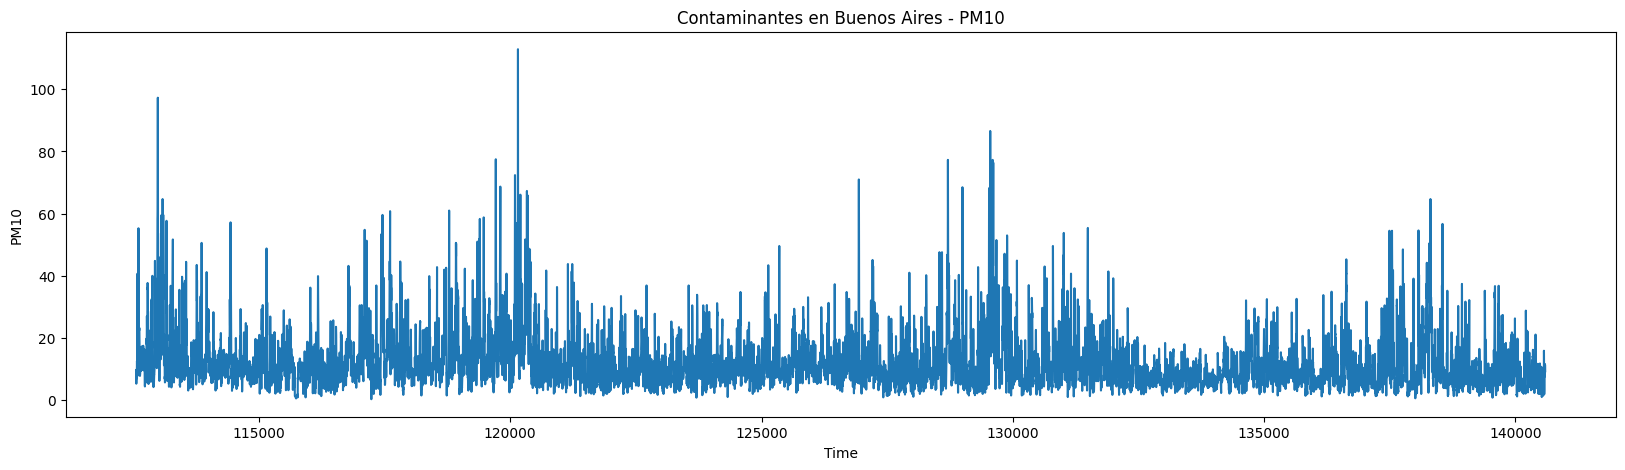

In [14]:
plt.figure(figsize = [20,5])
plt.plot(data.pm10_openmeteo)
plt.title("Contaminantes en Buenos Aires - PM10")
plt.xlabel("Time")
plt.ylabel("PM10")
plt.show()

In [15]:
train_percentage = 0.67
train_size = int(len(data)*train_percentage)

train = data["pm10_openmeteo"][:train_size].values.astype(float)
test = data["pm10_openmeteo"][train_size:].values.astype(float)

sc = MinMaxScaler(feature_range=(-1, 1))
train_norm = sc.fit_transform(train .reshape(-1, 1))

train_norm = torch.FloatTensor(train_norm).view(-1)

In [16]:
np.shape(train_norm)

torch.Size([18783])

In [17]:
def create_input_output(input_data, window, ndays = 1):
    input_output = []
    data_size = len(input_data)
    for i in range(data_size - window - ndays):
        train_seq = input_data[i:i+window]
        train_label = input_data[i+window+ndays:i+window+ndays+1]
        input_output.append((train_seq ,train_label))
    return input_output
ndays = 10
window = 30
train_input_output = create_input_output(train_norm, window, ndays)
train_input_output[:2]

[(tensor([-0.8330, -0.8579, -0.8828, -0.8970, -0.9112, -0.9076, -0.8988, -0.8881,
          -0.8757, -0.8703, -0.8650, -0.8384, -0.8650, -0.8810, -0.8597, -0.8277,
          -0.7993, -0.7815, -0.7869, -0.8242, -0.8561, -0.8455, -0.7922, -0.7336,
          -0.7211, -0.5187, -0.3357, -0.2824, -0.3481, -0.4636]),
  tensor([-0.6856])),
 (tensor([-0.8579, -0.8828, -0.8970, -0.9112, -0.9076, -0.8988, -0.8881, -0.8757,
          -0.8703, -0.8650, -0.8384, -0.8650, -0.8810, -0.8597, -0.8277, -0.7993,
          -0.7815, -0.7869, -0.8242, -0.8561, -0.8455, -0.7922, -0.7336, -0.7211,
          -0.5187, -0.3357, -0.2824, -0.3481, -0.4636, -0.5915]),
  tensor([-0.6856]))]

In [18]:
# Documentation of pytorch Conv1D: https://pytorch.org/docs/stable/generated/torch.nn.Conv1d.html
class NN_conv(nn.Module):
    def __init__(self):
        super(NN_conv, self).__init__()
        self.conv1 = nn.Sequential(         
            nn.Conv1d(
                in_channels=1,             # Number of channels in the input image
                out_channels=5,            # Number of channels produced by the convolution
                kernel_size=5,             # Size of the convolving kernel 
                stride=1,                  # Stride of the convolution. Default: 1 
                padding=2,                 # Zero-padding added to both sides of the input. Default: 0 
            ),                              
            nn.ReLU(),                      
            nn.MaxPool1d(kernel_size=3),
        )
        self.conv2 = nn.Sequential(         
            nn.Conv1d(
                in_channels=5,             
                out_channels=8,             
                kernel_size=5,              
                stride=1,                   
                padding=2,                  
            ),                              
            nn.ReLU(),                      
            nn.MaxPool1d(kernel_size=2),    
            
        )
        self.out = nn.Linear(40, 1)  #output 3 classes: Cargo, Passenger or Fishing


    def forward(self, x):
        #print(x.size())
        x = self.conv1(x)
        #print(x.size())
        x = self.conv2(x)
        #print(x.size())
        x = x.view(-1, 8 * 5)
        #print(x.size())
        output = self.out(x)
        return output


net = NN_conv()

In [19]:
model = NN_conv()
loss_function = nn.MSELoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) #torch.optim.SGD(model.parameters(), lr=0.001)

In [20]:
epochs = 100

for i in range(epochs):
    for inputs, labels in train_input_output:
        optimizer.zero_grad()
        inputs = inputs.view(1,1,window) # (N,C,L) N is a batch size, C denotes a number of channels, L is a length of signal sequence. https://pytorch.org/docs/stable/generated/torch.nn.Conv1d.html
        y_pred = model(inputs)

        single_loss = loss_function(y_pred, labels)
        single_loss.backward()
        optimizer.step()

    if i%10 == 1:
        print(f'epoch: {i:3} loss: {single_loss.item():10.8f}')

print(f'epoch: {i:3} loss: {single_loss.item():10.10f}')

/home/bita/.pyenv/versions/medios_federales/lib/python3.10/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


epoch:   1 loss: 0.01260705
epoch:  11 loss: 0.01092244
epoch:  21 loss: 0.01092244
epoch:  31 loss: 0.01092244
epoch:  41 loss: 0.01092244
epoch:  51 loss: 0.01092244
epoch:  61 loss: 0.01092244
epoch:  71 loss: 0.01092244
epoch:  81 loss: 0.01092244
epoch:  91 loss: 0.01092244
epoch:  99 loss: 0.0109224413


In [21]:
test_norm = sc.transform(test.reshape(-1, 1))
test_norm = torch.FloatTensor(test_norm).view(-1)
test_input_output = create_input_output(test_norm, window, ndays)
test_input_output[:2]

[(tensor([-0.8686, -0.8650, -0.8686, -0.8774, -0.8881, -0.8952, -0.8952, -0.8863,
          -0.8810, -0.8970, -0.8668, -0.8419, -0.8135, -0.7726, -0.7869, -0.7815,
          -0.7851, -0.7886, -0.7975, -0.8099, -0.8206, -0.8259, -0.8295, -0.8224,
          -0.7869, -0.7584, -0.7584, -0.7904, -0.8242, -0.8384]),
  tensor([-0.9520])),
 (tensor([-0.8650, -0.8686, -0.8774, -0.8881, -0.8952, -0.8952, -0.8863, -0.8810,
          -0.8970, -0.8668, -0.8419, -0.8135, -0.7726, -0.7869, -0.7815, -0.7851,
          -0.7886, -0.7975, -0.8099, -0.8206, -0.8259, -0.8295, -0.8224, -0.7869,
          -0.7584, -0.7584, -0.7904, -0.8242, -0.8384, -0.8419]),
  tensor([-0.9449]))]

In [22]:
y_pred_norm = []
for inputs, labels in test_input_output:
    with torch.no_grad():
        inputs = inputs.view(1,1,window)
        y_pred_norm.append(model(inputs).item())
y_pred_norm[:5]

[-0.7644876837730408,
 -0.7644876837730408,
 -0.7644876837730408,
 -0.7644876837730408,
 -0.7644876837730408]

In [23]:
y_pred = sc.inverse_transform(np.array(y_pred_norm).reshape(-1, 1))
y_pred[:5]

array([[13.5593434],
       [13.5593434],
       [13.5593434],
       [13.5593434],
       [13.5593434]])

In [24]:
y_true = test[window+ndays:]

In [25]:
mean_squared_error(y_true, y_pred)

60.47887332663998

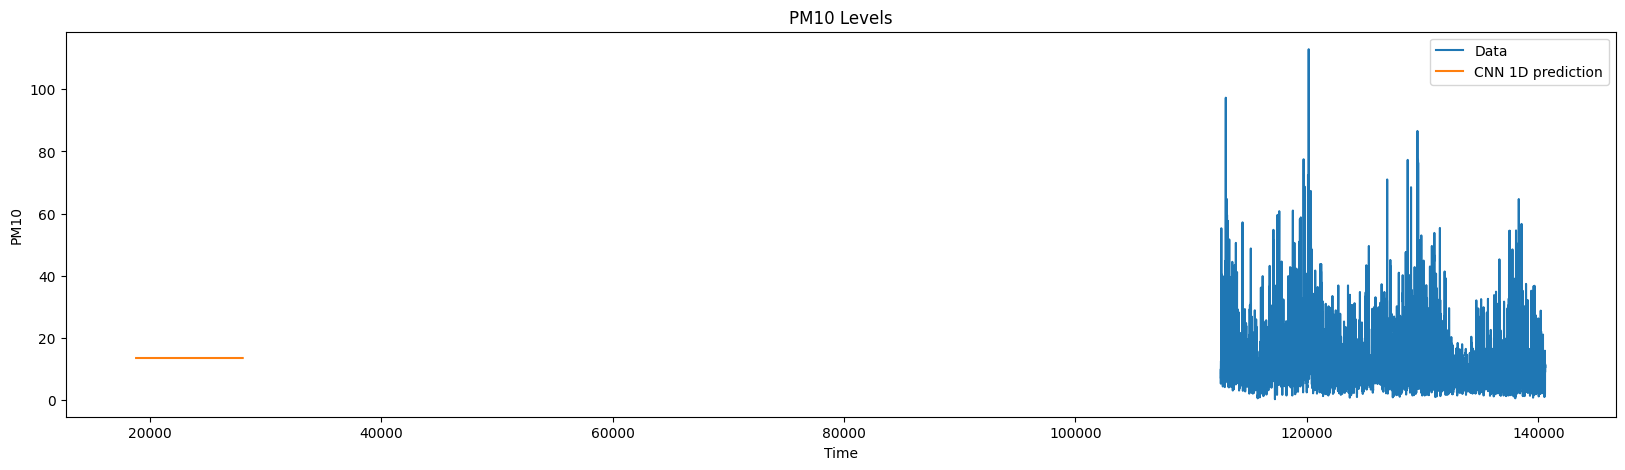

In [27]:
plt.figure(figsize = [20,5])
plt.plot(data.pm10_openmeteo, label="Data")
plt.plot(range(len(train)+window+ndays, len(train) + len(test)), y_pred, label="CNN 1D prediction")
plt.title("PM10 Levels")
plt.xlabel("Time")
plt.ylabel("PM10")
plt.legend()
plt.show()